#Preprocessing


In [ ]:
!pip -q install nibabel nilearn scipy tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 108.6 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
import os
import glob
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

from tqdm import tqdm
from nilearn.datasets import load_mni152_template
from nilearn.image import resample_to_img, resample_img
from scipy.ndimage import zoom

In [ ]:
RAW_BASE = "/content/drive/MyDrive/ADNI Only dataset"
OUT_BASE = "/content/drive/MyDrive/ADNI_Aligned"

GROUPS = ["CN", "MCI", "AD"]

for g in GROUPS:
    os.makedirs(os.path.join(OUT_BASE, g), exist_ok=True)

print("Output:", OUT_BASE)

Output: /content/drive/MyDrive/ADNI_Aligned


In [ ]:
mni = load_mni152_template()

print("MNI shape:", mni.shape)
print("Affine:\n", mni.affine)

MNI shape: (197, 233, 189)
Affine:
 [[   1.    0.    0.  -98.]
 [   0.    1.    0. -134.]
 [   0.    0.    1.  -72.]
 [   0.    0.    0.    1.]]


In [ ]:
def normalize_percentile(img):
    p1 = np.percentile(img, 1)
    p99 = np.percentile(img, 99)

    img = np.clip(img, p1, p99)

    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    return img


def resize_volume(vol, target=(96, 96, 96)):
    factors = [
        target[0] / vol.shape[0],
        target[1] / vol.shape[1],
        target[2] / vol.shape[2],
    ]

    return zoom(vol, factors, order=1)


def preprocess_scan(in_path, out_path):
    try:
        img = nib.load(in_path)

        # canonical orientation
        img = nib.as_closest_canonical(img)

        # affine align to MNI space
        aligned = resample_to_img(
            source_img=img,
            target_img=mni,
            interpolation="continuous"
        )

        data = aligned.get_fdata()

        # normalize
        data = normalize_percentile(data)

        # resize
        data = resize_volume(data, target=(96, 96, 96))

        out_img = nib.Nifti1Image(
            data.astype(np.float32),
            np.eye(4)
        )

        nib.save(out_img, out_path)

        return True

    except Exception as e:
        print("FAILED:", in_path)
        print(e)
        return False

In [ ]:
total = 0
done = 0
failed = []

for group in GROUPS:
    files = glob.glob(os.path.join(RAW_BASE, group, "*.nii"))
    files += glob.glob(os.path.join(RAW_BASE, group, "*.nii.gz"))

    print(f"\n{group}: {len(files)} scans")

    total += len(files)

    for f in tqdm(files):
        name = os.path.basename(f)

        out_path = os.path.join(
            OUT_BASE,
            group,
            name.replace(".nii", ".nii.gz")
        )

        if os.path.exists(out_path):
            done += 1
            continue

        ok = preprocess_scan(f, out_path)

        if ok:
            done += 1
        else:
            failed.append(f)

print("\nDONE:", done)
print("FAILED:", len(failed))


CN: 134 scans


100%|██████████| 134/134 [00:00<00:00, 1472.88it/s]



MCI: 150 scans


100%|██████████| 150/150 [00:00<00:00, 1962.83it/s]



AD: 122 scans


100%|██████████| 122/122 [1:56:23<00:00, 57.24s/it] 


DONE: 406
FAILED: 0


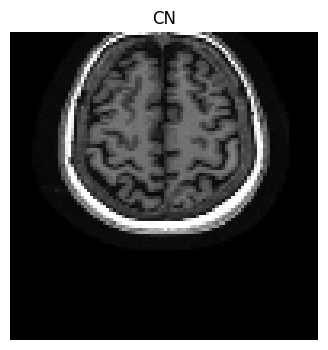

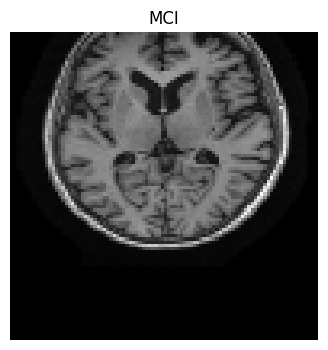

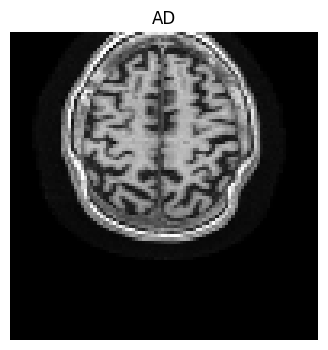

In [ ]:
def show_middle(path, title):
    img = nib.load(path)
    data = img.get_fdata()

    mid = data.shape[2] // 2

    plt.figure(figsize=(4,4))
    plt.imshow(data[:, :, mid].T, cmap="gray", origin="lower")
    plt.title(title)
    plt.axis("off")
    plt.show()


for group in GROUPS:
    files = glob.glob(os.path.join(OUT_BASE, group, "*.nii.gz"))
    if files:
        show_middle(files[0], group)

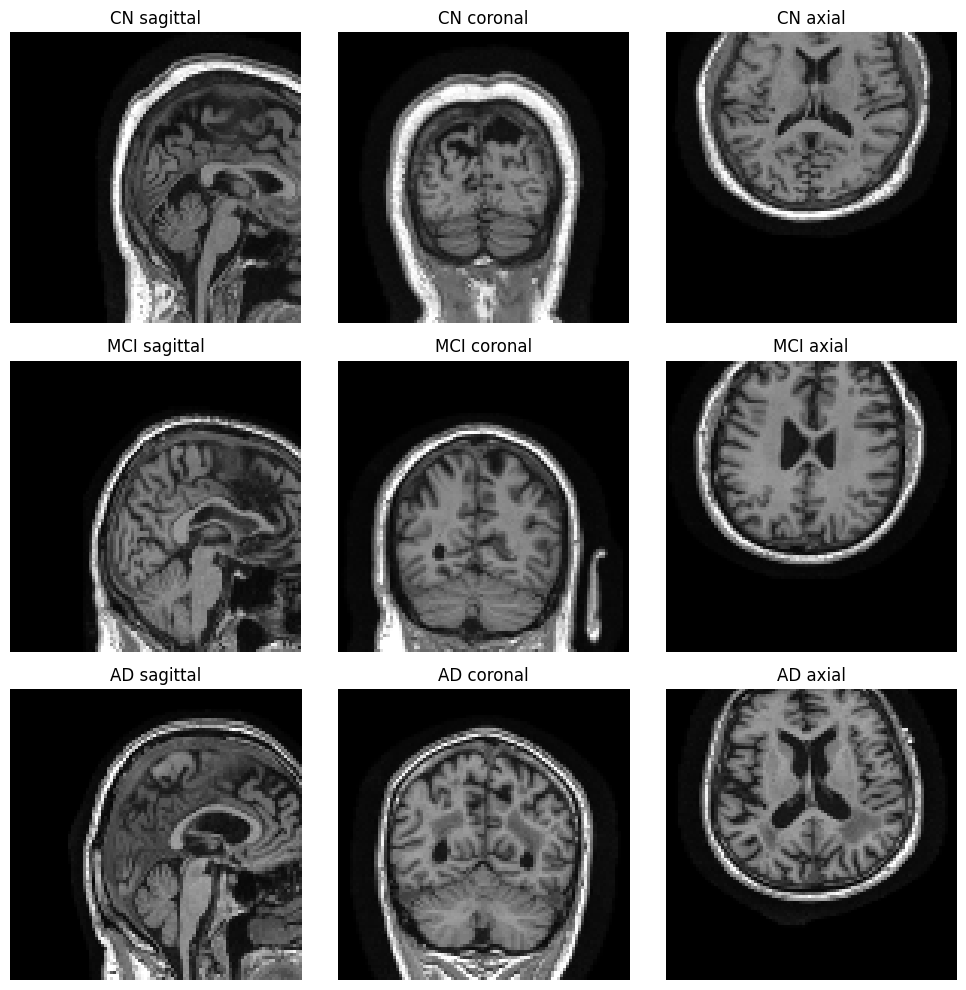

In [ ]:
import os
import glob
import random
import nibabel as nib
import matplotlib.pyplot as plt

BASE = "/content/drive/MyDrive/ADNI_Aligned"

groups = ["CN", "MCI", "AD"]

fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for i, group in enumerate(groups):
    f = random.choice(glob.glob(os.path.join(BASE, group, "*.nii.gz")))

    img = nib.load(f).get_fdata()

    x = img.shape[0] // 2
    y = img.shape[1] // 2
    z = img.shape[2] // 2

    axes[i, 0].imshow(img[x, :, :].T, cmap="gray", origin="lower")
    axes[i, 0].set_title(f"{group} sagittal")

    axes[i, 1].imshow(img[:, y, :].T, cmap="gray", origin="lower")
    axes[i, 1].set_title(f"{group} coronal")

    axes[i, 2].imshow(img[:, :, z].T, cmap="gray", origin="lower")
    axes[i, 2].set_title(f"{group} axial")

for ax in axes.ravel():
    ax.axis("off")

plt.tight_layout()
plt.show()

#FOLD

In [ ]:
# ============================================================
# PATCH 1 — 5-FOLD DATASET SETUP
# ============================================================
from google.colab import drive

drive.mount('/content/drive')

!pip -q install monai nibabel scikit-learn

import os
import glob
import random
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import StratifiedKFold

from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    ResizeWithPadOrCropd,
    EnsureTyped,
    RandFlipd,
    RandRotate90d,
    RandGaussianNoised
)

from monai.data import PersistentDataset, DataLoader

# -------------------------
# CONFIG
# -------------------------
BASE = "/content/drive/MyDrive/ADNI_Aligned"
CKPT_DIR = "/content/drive/MyDrive/cv_checkpoints"

IMG_SIZE = (96, 96, 96)
BATCH_SIZE = 4
SEED = 42
N_FOLDS = 5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

os.makedirs(CKPT_DIR, exist_ok=True)

# -------------------------
# BUILD DATAFRAME
# -------------------------
records = []

for cls, label in [("CN", 0), ("AD", 1)]:
    files = glob.glob(os.path.join(BASE, cls, "*.nii.gz"))

    for f in files:
        records.append({
            "image": f,
            "label": label
        })

df = pd.DataFrame(records)

print("Total samples:", len(df))
print(df["label"].value_counts())

# -------------------------
# TRANSFORMS
# -------------------------
train_tfm = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),

    ResizeWithPadOrCropd(
        keys=["image"],
        spatial_size=IMG_SIZE
    ),

    RandFlipd(
        keys=["image"],
        prob=0.3,
        spatial_axis=0
    ),

    RandRotate90d(
        keys=["image"],
        prob=0.2,
        max_k=1
    ),

    RandGaussianNoised(
        keys=["image"],
        prob=0.1,
        mean=0.0,
        std=0.01
    ),

    EnsureTyped(
        keys=["image", "label"],
        track_meta=False
    )
])

val_tfm = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),

    ResizeWithPadOrCropd(
        keys=["image"],
        spatial_size=IMG_SIZE
    ),

    EnsureTyped(
        keys=["image", "label"],
        track_meta=False
    )
])

print("PATCH 1 DONE")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Total samples: 256
label
0    134
1    122
Name: count, dtype: int64
PATCH 1 DONE


In [ ]:
# ============================================================
# PATCH 2 — 5-FOLD RESNET10 TRAINING
# ============================================================

import torch.nn as nn
from monai.networks.nets import resnet10
from sklearn.metrics import accuracy_score, classification_report

skf = StratifiedKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=SEED
)

fold_scores = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(df, df["label"])
):

    print("\n" + "="*60)
    print(f"FOLD {fold+1}/{N_FOLDS}")
    print("="*60)

    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    # -------------------------
    # CLEAN CACHE
    # -------------------------
    train_cache = f"/content/cache_train_fold_{fold}"
    val_cache   = f"/content/cache_val_fold_{fold}"

    !rm -rf {train_cache}
    !rm -rf {val_cache}

    # -------------------------
    # DATASETS
    # -------------------------
    train_ds = PersistentDataset(
        data=train_df.to_dict("records"),
        transform=train_tfm,
        cache_dir=train_cache
    )

    val_ds = PersistentDataset(
        data=val_df.to_dict("records"),
        transform=val_tfm,
        cache_dir=val_cache
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2
    )

    # -------------------------
    # MODEL
    # -------------------------
    classifier = resnet10(
        spatial_dims=3,
        n_input_channels=1,
        num_classes=2
    )

    classifier.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(classifier.fc.in_features, 2)
    )

    classifier = classifier.to(device)

    # -------------------------
    # SOFT FREEZE
    # -------------------------
    for name, param in classifier.named_parameters():
        if "layer1" in name:
            param.requires_grad = False

    # -------------------------
    # LOSS
    # -------------------------
    counts = train_df["label"].value_counts().sort_index().values
    weights = 1.0 / counts
    weights = weights / weights.sum()
    weights = torch.tensor(
        weights,
        dtype=torch.float32
    ).to(device)

    criterion = nn.CrossEntropyLoss(
        weight=weights,
        label_smoothing=0.05
    )

    # -------------------------
    # OPTIMIZER
    # -------------------------
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, classifier.parameters()),
        lr=1e-4,
        weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=4
    )

    scaler = torch.amp.GradScaler('cuda')

    # -------------------------
    # FUNCTIONS
    # -------------------------
    def train_one_epoch():
        classifier.train()

        losses = []
        preds = []
        trues = []

        for batch in train_loader:
            imgs = batch["image"].to(device)
            labels = batch["label"].long().to(device)

            optimizer.zero_grad()

            with torch.amp.autocast('cuda'):
                logits = classifier(imgs)
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()

            torch.nn.utils.clip_grad_norm_(
                classifier.parameters(),
                1.0
            )

            scaler.step(optimizer)
            scaler.update()

            losses.append(loss.item())

            pred = torch.argmax(logits, dim=1)

            preds.extend(pred.cpu().numpy())
            trues.extend(labels.cpu().numpy())

        return np.mean(losses), accuracy_score(trues, preds)

    def evaluate():
        classifier.eval()

        losses = []
        preds = []
        trues = []

        with torch.no_grad():
            for batch in val_loader:
                imgs = batch["image"].to(device)
                labels = batch["label"].long().to(device)

                with torch.amp.autocast('cuda'):
                    logits = classifier(imgs)
                    loss = criterion(logits, labels)

                losses.append(loss.item())

                pred = torch.argmax(logits, dim=1)

                preds.extend(pred.cpu().numpy())
                trues.extend(labels.cpu().numpy())

        return np.mean(losses), accuracy_score(trues, preds)

    # -------------------------
    # TRAIN LOOP
    # -------------------------
    EPOCHS = 30
    PATIENCE = 8

    best_val_acc = 0
    counter = 0

    for epoch in range(EPOCHS):

        train_loss, train_acc = train_one_epoch()
        val_loss, val_acc = evaluate()

        scheduler.step(val_loss)

        print(
            f"Fold {fold+1} | "
            f"Epoch {epoch+1}/{EPOCHS} | "
            f"train={train_acc:.3f} | "
            f"val={val_acc:.3f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            counter = 0

            torch.save(
                classifier.state_dict(),
                f"{CKPT_DIR}/fold_{fold+1}.pth"
            )

        else:
            counter += 1

        if counter >= PATIENCE:
            print("Early stopping")
            break

    fold_scores.append(best_val_acc)

# -------------------------
# FINAL RESULTS
# -------------------------
print("\n" + "="*60)
print("5-FOLD RESULTS")
print("="*60)

for i, score in enumerate(fold_scores):
    print(f"Fold {i+1}: {score:.4f}")

print(
    f"\nMean Accuracy: {np.mean(fold_scores):.4f}"
)

print(
    f"Std Dev: {np.std(fold_scores):.4f}"
)


FOLD 1/5
Fold 1 | Epoch 1/30 | train=0.510 | val=0.519
Fold 1 | Epoch 2/30 | train=0.500 | val=0.558
Fold 1 | Epoch 3/30 | train=0.525 | val=0.481
Fold 1 | Epoch 4/30 | train=0.583 | val=0.558
Fold 1 | Epoch 5/30 | train=0.598 | val=0.519
Fold 1 | Epoch 6/30 | train=0.623 | val=0.519
Fold 1 | Epoch 7/30 | train=0.623 | val=0.519
Fold 1 | Epoch 8/30 | train=0.652 | val=0.481
Fold 1 | Epoch 9/30 | train=0.662 | val=0.519
Fold 1 | Epoch 10/30 | train=0.657 | val=0.750
Fold 1 | Epoch 11/30 | train=0.686 | val=0.750
Fold 1 | Epoch 12/30 | train=0.711 | val=0.481
Fold 1 | Epoch 13/30 | train=0.740 | val=0.519
Fold 1 | Epoch 14/30 | train=0.740 | val=0.538
Fold 1 | Epoch 15/30 | train=0.750 | val=0.481
Fold 1 | Epoch 16/30 | train=0.794 | val=0.519
Fold 1 | Epoch 17/30 | train=0.804 | val=0.538
Fold 1 | Epoch 18/30 | train=0.809 | val=0.635
Early stopping

FOLD 2/5
Fold 2 | Epoch 1/30 | train=0.493 | val=0.529
Fold 2 | Epoch 2/30 | train=0.551 | val=0.529
Fold 2 | Epoch 3/30 | train=0.537 | 

#Training Pipeline 2 - Use this for report (same preprocessing)

In [ ]:
# ============================================================
# PATCH 1 — MULTITASK DATASET + MODEL
# ============================================================

!pip -q install monai nibabel scikit-learn

import os
import glob
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split

from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    ResizeWithPadOrCropd,
    EnsureTyped,
    RandFlipd,
    RandGaussianNoised
)

from monai.data import PersistentDataset, DataLoader
from monai.networks.nets import resnet10

# -------------------------
# CONFIG
# -------------------------
BASE = "/content/drive/MyDrive/ADNI_Aligned"
CSV_DIR = "/content/drive/MyDrive/ADNI Only dataset"
PRETRAINED = "/content/drive/MyDrive/cv_checkpoints/fold_1.pth"
SAVE_PATH = "/content/drive/MyDrive/multitask_brain_age.pth"

IMG_SIZE = (96, 96, 96)
BATCH_SIZE = 4
SEED = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# -------------------------
# LOAD CSV
# -------------------------
cn_csv = pd.read_csv(f"{CSV_DIR}/CN_ADNI.csv")
ad_csv = pd.read_csv(f"{CSV_DIR}/AD_ADNI.csv")

cn_csv["Group"] = "CN"
ad_csv["Group"] = "AD"

meta = pd.concat([cn_csv, ad_csv], ignore_index=True)
meta = meta[["Subject", "Group", "Age"]].drop_duplicates()

# -------------------------
# BUILD DATAFRAME
# -------------------------
records = []

for grp, label in [("CN", 0), ("AD", 1)]:
    files = glob.glob(os.path.join(BASE, grp, "*.nii.gz"))

    for f in files:
        subject = os.path.basename(f).replace(".nii.gz", "")

        row = meta[
            (meta["Subject"] == subject) &
            (meta["Group"] == grp)
        ]

        if len(row) == 0:
            continue

        age = float(row.iloc[0]["Age"])

        records.append({
            "image": f,
            "label": label,
            "age": age
        })

df = pd.DataFrame(records)

print(df["label"].value_counts())

AGE_MIN = df["age"].min()
AGE_MAX = df["age"].max()

print("Age range:", AGE_MIN, AGE_MAX)

# -------------------------
# SPLIT
# -------------------------
train_df, val_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=SEED
)

print("Train:", len(train_df))
print("Val:", len(val_df))

# -------------------------
# TRANSFORMS
# -------------------------
train_tfm = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),

    ResizeWithPadOrCropd(
        keys=["image"],
        spatial_size=IMG_SIZE
    ),

    RandFlipd(
        keys=["image"],
        prob=0.3,
        spatial_axis=0
    ),

    RandGaussianNoised(
        keys=["image"],
        prob=0.1,
        mean=0.0,
        std=0.01
    ),

    EnsureTyped(
        keys=["image"],
        track_meta=False
    )
])

val_tfm = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),

    ResizeWithPadOrCropd(
        keys=["image"],
        spatial_size=IMG_SIZE
    ),

    EnsureTyped(
        keys=["image"],
        track_meta=False
    )
])

# -------------------------
# DATASET
# -------------------------
train_ds = PersistentDataset(
    train_df.to_dict("records"),
    train_tfm,
    cache_dir="/content/mt_train_cache"
)

val_ds = PersistentDataset(
    val_df.to_dict("records"),
    val_tfm,
    cache_dir="/content/mt_val_cache"
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

# -------------------------
# MULTITASK MODEL
# -------------------------
class MultiTaskResNet(nn.Module):
    def __init__(self):
        super().__init__()

        backbone = resnet10(
            spatial_dims=3,
            n_input_channels=1,
            num_classes=2
        )

        in_features = backbone.fc.in_features

        backbone.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, 2)
        )

        state = torch.load(PRETRAINED, map_location="cpu")
        backbone.load_state_dict(state)

        self.backbone = backbone
        self.backbone.fc = nn.Identity()

        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, 2)
        )

        self.regressor = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        feats = self.backbone(x)

        cls = self.classifier(feats)
        age = self.regressor(feats)

        return cls, age

model = MultiTaskResNet().to(device)

# freeze early layers
# freeze early pretrained layers
for param in model.backbone.conv1.parameters():
    param.requires_grad = False

for param in model.backbone.bn1.parameters():
    param.requires_grad = False

for param in model.backbone.layer1.parameters():
    param.requires_grad = False

print("Model ready.")

Device: cuda
label
0    134
1    122
Name: count, dtype: int64
Age range: 56.0 91.0
Train: 204
Val: 52
Model ready.


In [ ]:
# ============================================================
# PATCH 2 — REFINED MULTITASK TRAINING
# CN-only regression + frozen early layers
# ============================================================

import math
from sklearn.metrics import accuracy_score, mean_absolute_error, r2_score

CLS_WEIGHT = 0.7
AGE_WEIGHT = 1.0

criterion_cls = nn.CrossEntropyLoss()
criterion_age = nn.SmoothL1Loss()
def pearson_corr_loss(pred, target):
    pred = pred.view(-1)
    target = target.view(-1)

    pred = pred - torch.mean(pred)
    target = target - torch.mean(target)

    corr = torch.sum(pred * target) / (
        torch.sqrt(torch.sum(pred ** 2)) *
        torch.sqrt(torch.sum(target ** 2)) +
        1e-8
    )

    return 1 - corr

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=2e-5,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=4
)

scaler = torch.amp.GradScaler('cuda')

BEST_SCORE = np.inf
PATIENCE = 20
counter = 0
EPOCHS = 50


# ============================================================
# TRAIN
# ============================================================

def train_one_epoch():

    model.train()

    losses = []
    cls_preds = []
    cls_true = []

    for batch in train_loader:

        imgs = batch["image"].to(device)
        labels = batch["label"].long().to(device)

        ages = batch["age"].float().to(device).unsqueeze(1)
        ages = (ages - AGE_MIN) / (AGE_MAX - AGE_MIN)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):

            cls_logits, age_preds = model(imgs)

            cls_loss = criterion_cls(
                cls_logits,
                labels
            )

            # CN-only age regression
            cn_mask = (labels == 0)
            if cn_mask.sum() > 1:

                huber_loss = criterion_age(
                    age_preds[cn_mask],
                    ages[cn_mask]
                )

                corr_loss = pearson_corr_loss(
                    age_preds[cn_mask],
                    ages[cn_mask]
                )

                age_loss = (
                    0.7 * huber_loss
                    +
                    0.3 * corr_loss
                )

            elif cn_mask.sum() == 1:

                age_loss = criterion_age(
                    age_preds[cn_mask],
                    ages[cn_mask]
                )

            else:
                age_loss = torch.tensor(
                    0.0,
                    device=device
                )

            total_loss = (
                CLS_WEIGHT * cls_loss
                +
                AGE_WEIGHT * age_loss
            )

        scaler.scale(total_loss).backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        scaler.step(optimizer)
        scaler.update()

        losses.append(total_loss.item())

        preds = torch.argmax(
            cls_logits,
            dim=1
        )

        cls_preds.extend(preds.cpu().numpy())
        cls_true.extend(labels.cpu().numpy())

    cls_acc = accuracy_score(
        cls_true,
        cls_preds
    )

    return np.mean(losses), cls_acc


# ============================================================
# VALIDATE
# ============================================================

def validate():

    model.eval()

    losses = []

    cls_preds = []
    cls_true = []

    age_preds_all = []
    age_true_all = []

    with torch.no_grad():

        for batch in val_loader:

            imgs = batch["image"].to(device)
            labels = batch["label"].long().to(device)

            ages_raw = batch["age"].float().to(device).unsqueeze(1)
            ages = (ages_raw - AGE_MIN) / (AGE_MAX - AGE_MIN)

            with torch.amp.autocast('cuda'):

                cls_logits, age_preds = model(imgs)

                cls_loss = criterion_cls(
                    cls_logits,
                    labels
                )

                cn_mask = (labels == 0)

                if cn_mask.sum() > 1:

                    huber_loss = criterion_age(
                        age_preds[cn_mask],
                        ages[cn_mask]
                    )

                    corr_loss = pearson_corr_loss(
                        age_preds[cn_mask],
                        ages[cn_mask]
                    )

                    age_loss = (
                        0.7 * huber_loss
                        +
                        0.3 * corr_loss
                    )

                elif cn_mask.sum() == 1:

                    age_loss = criterion_age(
                        age_preds[cn_mask],
                        ages[cn_mask]
                    )

                else:
                    age_loss = torch.tensor(
                        0.0,
                        device=device
                    )

                total_loss = (
                    CLS_WEIGHT * cls_loss
                    +
                    AGE_WEIGHT * age_loss
                )

            losses.append(total_loss.item())

            preds = torch.argmax(
                cls_logits,
                dim=1
            )

            cls_preds.extend(preds.cpu().numpy())
            cls_true.extend(labels.cpu().numpy())

            age_denorm = (
                age_preds * (AGE_MAX - AGE_MIN)
            ) + AGE_MIN

            age_preds_all.extend(
                np.atleast_1d(
                    age_denorm.squeeze().cpu().numpy()
                )
            )

            age_true_all.extend(
                np.atleast_1d(
                    ages_raw.squeeze().cpu().numpy()
                )
            )

    cls_acc = accuracy_score(
        cls_true,
        cls_preds
    )

    mae = mean_absolute_error(
        age_true_all,
        age_preds_all
    )

    rmse = math.sqrt(
        np.mean(
            (
                np.array(age_true_all)
                -
                np.array(age_preds_all)
            ) ** 2
        )
    )

    r2 = r2_score(
        age_true_all,
        age_preds_all
    )

    return np.mean(losses), cls_acc, mae, rmse, r2


# ============================================================
# TRAIN LOOP
# ============================================================

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch()

    val_loss, val_acc, mae, rmse, r2 = validate()

    scheduler.step(val_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"train_acc={train_acc:.3f} | "
        f"val_acc={val_acc:.3f} | "
        f"MAE={mae:.2f} | "
        f"RMSE={rmse:.2f} | "
        f"R2={r2:.3f}"
    )
    score=mae
    if score < BEST_SCORE:

        BEST_SCORE = score
        counter = 0

        torch.save(
            model.state_dict(),
            SAVE_PATH
        )

        print("Saved best multitask model.")

    else:
        counter += 1

    if counter >= PATIENCE:
        print("Early stopping.")
        break

print("TRAINING COMPLETE")

Epoch 1/50 | train_acc=0.539 | val_acc=0.673 | MAE=5.88 | RMSE=7.01 | R2=-0.197
Saved best multitask model.
Epoch 2/50 | train_acc=0.686 | val_acc=0.558 | MAE=4.87 | RMSE=6.23 | R2=0.056
Saved best multitask model.
Epoch 3/50 | train_acc=0.725 | val_acc=0.750 | MAE=5.56 | RMSE=6.98 | R2=-0.187
Epoch 4/50 | train_acc=0.716 | val_acc=0.692 | MAE=5.00 | RMSE=6.19 | R2=0.067
Epoch 5/50 | train_acc=0.779 | val_acc=0.500 | MAE=4.98 | RMSE=6.43 | R2=-0.008
Epoch 6/50 | train_acc=0.838 | val_acc=0.635 | MAE=4.97 | RMSE=6.43 | R2=-0.008
Epoch 7/50 | train_acc=0.858 | val_acc=0.788 | MAE=4.63 | RMSE=5.85 | R2=0.167
Saved best multitask model.
Epoch 8/50 | train_acc=0.824 | val_acc=0.769 | MAE=4.63 | RMSE=5.92 | R2=0.146
Epoch 9/50 | train_acc=0.897 | val_acc=0.712 | MAE=4.59 | RMSE=5.92 | R2=0.146
Saved best multitask model.
Epoch 10/50 | train_acc=0.882 | val_acc=0.558 | MAE=5.05 | RMSE=6.29 | R2=0.036
Epoch 11/50 | train_acc=0.882 | val_acc=0.519 | MAE=4.60 | RMSE=6.04 | R2=0.113
Epoch 12/50 |

In [ ]:
# ============================================================
# MULTITASK EVALUATION METRICS
# ============================================================

from sklearn.metrics import accuracy_score, mean_absolute_error, r2_score
from scipy.stats import pearsonr
import numpy as np
import math

# load best saved model
model.load_state_dict(torch.load(SAVE_PATH))
model.eval()

cls_preds = []
cls_true = []

age_preds_all = []
age_true_all = []

with torch.no_grad():
    for batch in val_loader:
        imgs = batch["image"].to(device)
        labels = batch["label"].long().to(device)

        ages_raw = batch["age"].float().to(device).unsqueeze(1)

        with torch.amp.autocast('cuda'):
            cls_logits, age_preds = model(imgs)

        preds = torch.argmax(cls_logits, dim=1)

        cls_preds.extend(preds.cpu().numpy())
        cls_true.extend(labels.cpu().numpy())

        # denormalize age prediction
        age_denorm = age_preds * (AGE_MAX - AGE_MIN) + AGE_MIN

        age_preds_all.extend(
            age_denorm.squeeze().cpu().numpy()
        )

        age_true_all.extend(
            ages_raw.squeeze().cpu().numpy()
        )

# classification
acc = accuracy_score(cls_true, cls_preds)

# regression
mae = mean_absolute_error(age_true_all, age_preds_all)

rmse = math.sqrt(np.mean(
    (np.array(age_true_all) - np.array(age_preds_all)) ** 2
))

r2 = r2_score(age_true_all, age_preds_all)

# Pearson correlation
pearson_r, pearson_p = pearsonr(
    age_true_all,
    age_preds_all
)

print("="*50)
print("MULTITASK MODEL EVALUATION")
print("="*50)

print(f"Classification Accuracy : {acc:.4f}")
print(f"MAE                     : {mae:.2f}")
print(f"RMSE                    : {rmse:.2f}")
print(f"R² Score                : {r2:.4f}")
print(f"Pearson Correlation (r) : {pearson_r:.4f}")
print(f"P-value                 : {pearson_p:.6f}")

MULTITASK MODEL EVALUATION
Classification Accuracy : 0.7692
MAE                     : 4.51
RMSE                    : 5.68
R² Score                : 0.2158
Pearson Correlation (r) : 0.4695
P-value                 : 0.000446


ABITHA AND AKASH, DONT USE THIS VISUALIZATION RESULTS FOR REPORT!!

Model saved at:
/content/drive/MyDrive/final_multitask_brain_age_model.pth
FINAL MODEL PERFORMANCE
Classification Accuracy : 0.9531
MAE                     : 4.19
RMSE                    : 5.57
R²                      : 0.2473
Pearson r               : 0.4975
P-value                 : 0.000000


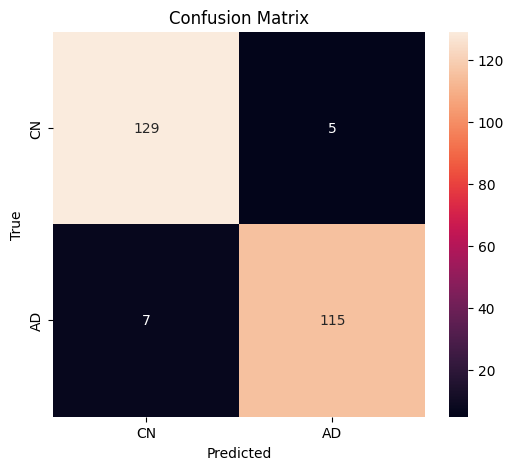

              precision    recall  f1-score   support

          CN       0.95      0.96      0.96       134
          AD       0.96      0.94      0.95       122

    accuracy                           0.95       256
   macro avg       0.95      0.95      0.95       256
weighted avg       0.95      0.95      0.95       256

                                               image  label   age  \
0  /content/drive/MyDrive/ADNI_Aligned/CN/127_S_0...      0  79.0   
1  /content/drive/MyDrive/ADNI_Aligned/CN/126_S_0...      0  76.0   
2  /content/drive/MyDrive/ADNI_Aligned/CN/126_S_0...      0  76.0   
3  /content/drive/MyDrive/ADNI_Aligned/CN/116_S_0...      0  76.0   
4  /content/drive/MyDrive/ADNI_Aligned/CN/116_S_1...      0  71.0   

   predicted_age  brain_age_gap group_name  
0        76.5000        -2.5000         CN  
1        79.3750         3.3750         CN  
2        73.3125        -2.6875         CN  
3        74.2500        -1.7500         CN  
4        73.8750         2.8750  

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


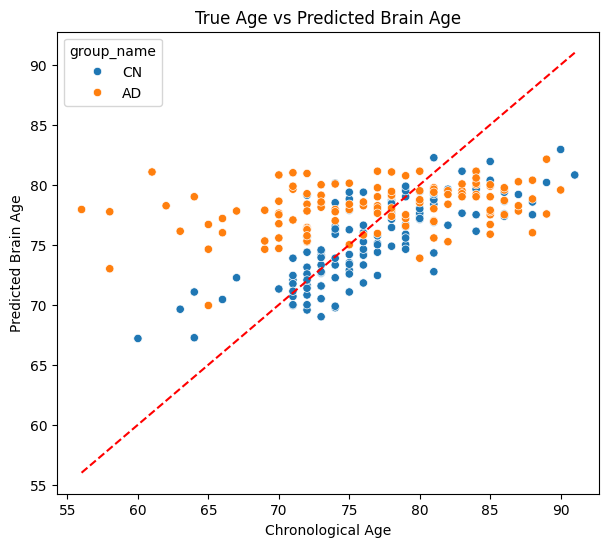

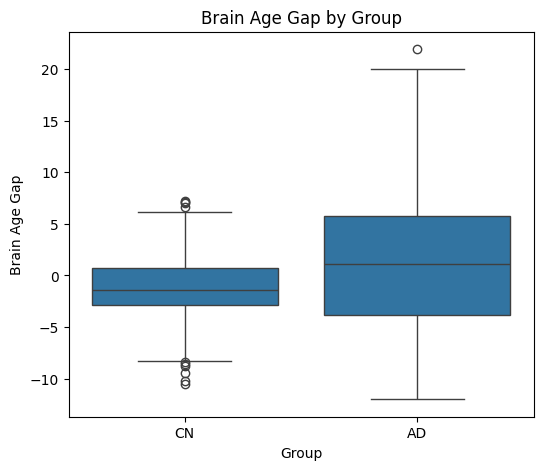

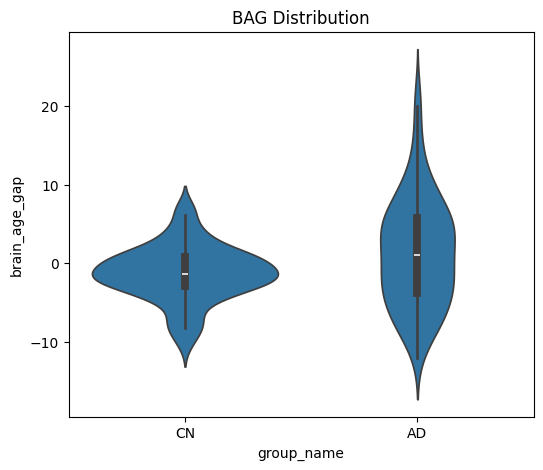

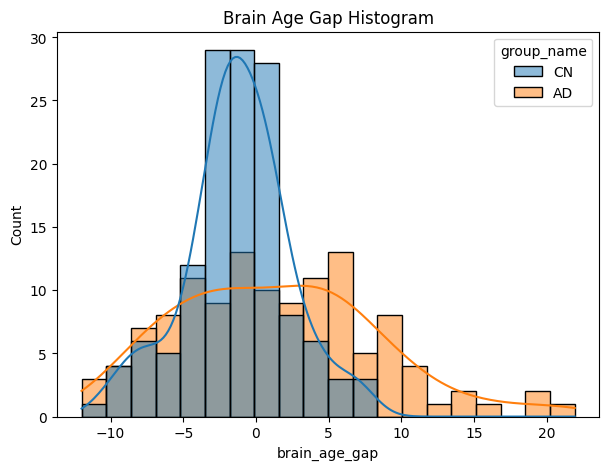

BAG STATISTICS
CN mean BAG: -1.2756529850746268
AD mean BAG: 1.350922131147541

T-test p-value: 0.00023074420308068572
Mann-Whitney p-value: 0.00216491819425914


In [ ]:
# ============================================================
# FINAL MULTITASK EVALUATION + BAG ANALYSIS (FULL DATASET) ABITHA AND AKASH, DONT USE THIS RESULTS FOR REPORT!!
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from scipy.stats import pearsonr, ttest_ind, mannwhitneyu
import math

# -------------------------
# SAVE FINAL MODEL
# -------------------------
FINAL_MODEL_PATH = "/content/drive/MyDrive/final_multitask_brain_age_model.pth"

torch.save(model.state_dict(), FINAL_MODEL_PATH)

print("Model saved at:")
print(FINAL_MODEL_PATH)

# -------------------------
# FULL DATASET LOADER
# -------------------------
full_tfm = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    ResizeWithPadOrCropd(
        keys=["image"],
        spatial_size=IMG_SIZE
    ),
    EnsureTyped(
        keys=["image"],
        track_meta=False
    )
])

full_ds = PersistentDataset(
    data=df.to_dict("records"),
    transform=full_tfm,
    cache_dir="/content/full_eval_cache"
)

full_loader = DataLoader(
    full_ds,
    batch_size=4,
    shuffle=False,
    num_workers=2
)

# -------------------------
# PREDICT ALL
# -------------------------
model.eval()

cls_preds = []
cls_true = []

age_preds = []
age_true = []
groups = []

with torch.no_grad():
    for batch in full_loader:
        imgs = batch["image"].to(device)
        labels = batch["label"].long().to(device)
        ages = batch["age"].float().to(device)

        with torch.amp.autocast('cuda'):
            cls_logits, pred_age = model(imgs)

        pred_cls = torch.argmax(cls_logits, dim=1)

        pred_age = pred_age * (AGE_MAX - AGE_MIN) + AGE_MIN

        cls_preds.extend(pred_cls.cpu().numpy())
        cls_true.extend(labels.cpu().numpy())

        age_preds.extend(pred_age.squeeze().cpu().numpy())
        age_true.extend(ages.cpu().numpy())

# -------------------------
# METRICS
# -------------------------
acc = accuracy_score(cls_true, cls_preds)

mae = mean_absolute_error(age_true, age_preds)

rmse = math.sqrt(np.mean(
    (np.array(age_true) - np.array(age_preds)) ** 2
))

r2 = r2_score(age_true, age_preds)

pearson_r, pearson_p = pearsonr(age_true, age_preds)

print("="*60)
print("FINAL MODEL PERFORMANCE")
print("="*60)

print(f"Classification Accuracy : {acc:.4f}")
print(f"MAE                     : {mae:.2f}")
print(f"RMSE                    : {rmse:.2f}")
print(f"R²                      : {r2:.4f}")
print(f"Pearson r               : {pearson_r:.4f}")
print(f"P-value                 : {pearson_p:.6f}")

# -------------------------
# CONFUSION MATRIX
# -------------------------
cm = confusion_matrix(cls_true, cls_preds)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=["CN", "AD"],
    yticklabels=["CN", "AD"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print(classification_report(
    cls_true,
    cls_preds,
    target_names=["CN", "AD"]
))

# -------------------------
# BAG
# -------------------------
results = df.copy()

results["predicted_age"] = age_preds
results["brain_age_gap"] = (
    results["predicted_age"] - results["age"]
)

results["group_name"] = results["label"].map({
    0: "CN",
    1: "AD"
})

print(results.head())

# -------------------------
# SCATTER
# -------------------------
plt.figure(figsize=(7,6))
sns.scatterplot(
    x=results["age"],
    y=results["predicted_age"],
    hue=results["group_name"]
)

plt.plot(
    [results["age"].min(), results["age"].max()],
    [results["age"].min(), results["age"].max()],
    'r--'
)

plt.title("True Age vs Predicted Brain Age")
plt.xlabel("Chronological Age")
plt.ylabel("Predicted Brain Age")
plt.show()

# -------------------------
# BAG BOXPLOT
# -------------------------
plt.figure(figsize=(6,5))
sns.boxplot(
    x="group_name",
    y="brain_age_gap",
    data=results
)

plt.title("Brain Age Gap by Group")
plt.xlabel("Group")
plt.ylabel("Brain Age Gap")
plt.show()

# -------------------------
# BAG VIOLIN
# -------------------------
plt.figure(figsize=(6,5))
sns.violinplot(
    x="group_name",
    y="brain_age_gap",
    data=results
)

plt.title("BAG Distribution")
plt.show()

# -------------------------
# BAG HISTOGRAM
# -------------------------
plt.figure(figsize=(7,5))
sns.histplot(
    data=results,
    x="brain_age_gap",
    hue="group_name",
    kde=True,
    bins=20
)

plt.title("Brain Age Gap Histogram")
plt.show()

# -------------------------
# STATISTICS
# -------------------------
cn_bag = results[
    results["group_name"] == "CN"
]["brain_age_gap"]

ad_bag = results[
    results["group_name"] == "AD"
]["brain_age_gap"]

print("="*60)
print("BAG STATISTICS")
print("="*60)

print("CN mean BAG:", cn_bag.mean())
print("AD mean BAG:", ad_bag.mean())

t_stat, t_p = ttest_ind(
    cn_bag,
    ad_bag,
    equal_var=False
)

mw_stat, mw_p = mannwhitneyu(
    cn_bag,
    ad_bag
)

print("\nT-test p-value:", t_p)
print("Mann-Whitney p-value:", mw_p)

USE THE VISUALIZATIONS BELOW FOR REPORT AND PPT

VALIDATION-ONLY MULTITASK EVALUATION
Classification Accuracy : 0.7692
MAE                     : 4.5088
RMSE                    : 5.6745
R² Score                : 0.216
Pearson Correlation (r) : 0.4698
P-value                 : 0.00044142808378467424

              precision    recall  f1-score   support

          CN       0.76      0.81      0.79        27
          AD       0.78      0.72      0.75        25

    accuracy                           0.77        52
   macro avg       0.77      0.77      0.77        52
weighted avg       0.77      0.77      0.77        52


VALIDATION BAG STATISTICS
CN mean BAG: -0.7419744
AD mean BAG: 0.26297334

T-test p-value: 0.5396267793190548
Mann-Whitney p-value: 0.7278551320420708


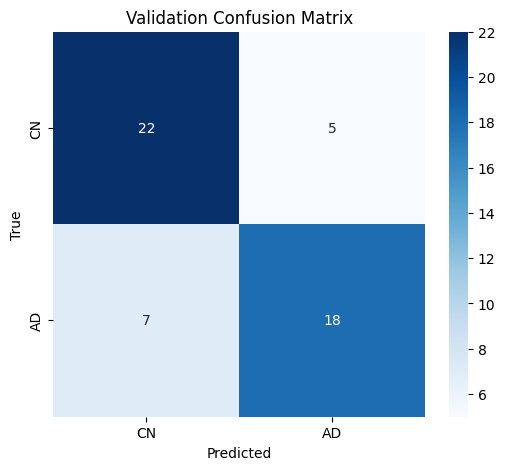

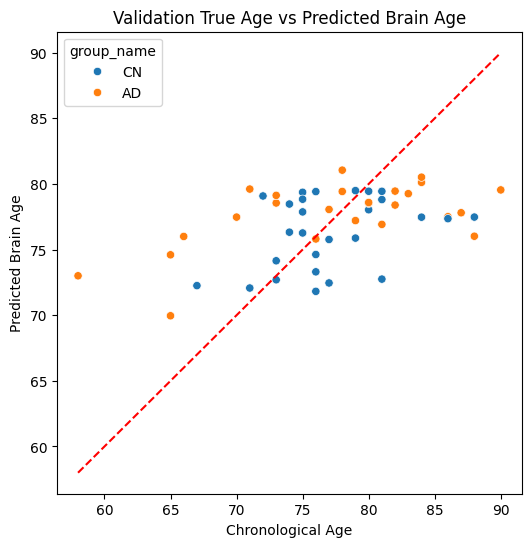

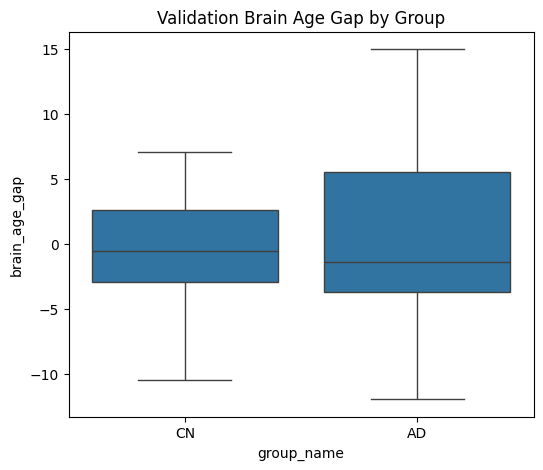

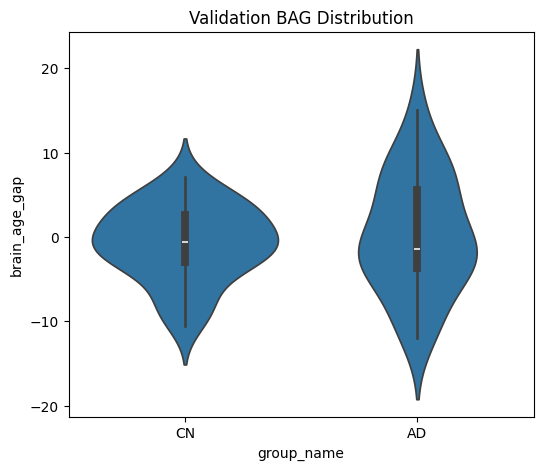

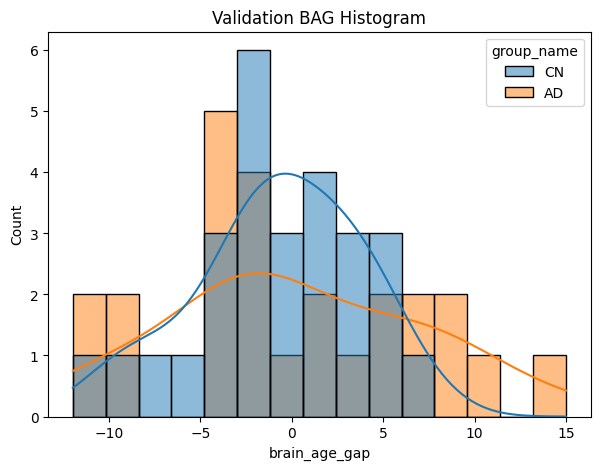


Saved validation BAG CSV.


In [ ]:
# ============================================================
# VALIDATION-ONLY BAG ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind, mannwhitneyu, pearsonr
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    r2_score
)

# load best saved model
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()

all_true_labels = []
all_pred_labels = []

all_true_ages = []
all_pred_ages = []

with torch.no_grad():

    for batch in val_loader:

        imgs = batch["image"].to(device)
        labels = batch["label"].long().to(device)

        ages_raw = batch["age"].float().to(device).unsqueeze(1)

        cls_logits, age_preds = model(imgs)

        preds = torch.argmax(cls_logits, dim=1)

        age_denorm = (
            age_preds * (AGE_MAX - AGE_MIN)
        ) + AGE_MIN

        all_true_labels.extend(
            labels.cpu().numpy()
        )

        all_pred_labels.extend(
            preds.cpu().numpy()
        )

        all_true_ages.extend(
            np.atleast_1d(
                ages_raw.squeeze().cpu().numpy()
            )
        )

        all_pred_ages.extend(
            np.atleast_1d(
                age_denorm.squeeze().cpu().numpy()
            )
        )

# ============================================================
# METRICS
# ============================================================

acc = accuracy_score(
    all_true_labels,
    all_pred_labels
)

mae = mean_absolute_error(
    all_true_ages,
    all_pred_ages
)

rmse = np.sqrt(np.mean(
    (
        np.array(all_true_ages)
        -
        np.array(all_pred_ages)
    ) ** 2
))

r2 = r2_score(
    all_true_ages,
    all_pred_ages
)

pearson_r, pearson_p = pearsonr(
    all_true_ages,
    all_pred_ages
)

print("="*60)
print("VALIDATION-ONLY MULTITASK EVALUATION")
print("="*60)

print("Classification Accuracy :", round(acc, 4))
print("MAE                     :", round(mae, 4))
print("RMSE                    :", round(rmse, 4))
print("R² Score                :", round(r2, 4))
print("Pearson Correlation (r) :", round(pearson_r, 4))
print("P-value                 :", pearson_p)

print()
print(classification_report(
    all_true_labels,
    all_pred_labels,
    target_names=["CN", "AD"]
))

# ============================================================
# BAG DATAFRAME
# ============================================================

results = pd.DataFrame({
    "true_label": all_true_labels,
    "pred_label": all_pred_labels,
    "true_age": all_true_ages,
    "pred_age": all_pred_ages
})

results["group_name"] = results["true_label"].map({
    0: "CN",
    1: "AD"
})

results["brain_age_gap"] = (
    results["pred_age"]
    -
    results["true_age"]
)

# ============================================================
# BAG STATS
# ============================================================

cn_bag = results[
    results["group_name"] == "CN"
]["brain_age_gap"]

ad_bag = results[
    results["group_name"] == "AD"
]["brain_age_gap"]

print("\n" + "="*60)
print("VALIDATION BAG STATISTICS")
print("="*60)

print("CN mean BAG:", cn_bag.mean())
print("AD mean BAG:", ad_bag.mean())

t_stat, t_p = ttest_ind(
    cn_bag,
    ad_bag,
    equal_var=False
)

mw_stat, mw_p = mannwhitneyu(
    cn_bag,
    ad_bag,
    alternative="two-sided"
)

print("\nT-test p-value:", t_p)
print("Mann-Whitney p-value:", mw_p)

# ============================================================
# PLOTS
# ============================================================

# confusion matrix
cm = confusion_matrix(
    all_true_labels,
    all_pred_labels
)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["CN", "AD"],
    yticklabels=["CN", "AD"]
)
plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# scatter
plt.figure(figsize=(6,6))
sns.scatterplot(
    data=results,
    x="true_age",
    y="pred_age",
    hue="group_name"
)

mn = results["true_age"].min()
mx = results["true_age"].max()

plt.plot(
    [mn, mx],
    [mn, mx],
    'r--'
)

plt.title("Validation True Age vs Predicted Brain Age")
plt.xlabel("Chronological Age")
plt.ylabel("Predicted Brain Age")
plt.show()

# boxplot
plt.figure(figsize=(6,5))
sns.boxplot(
    data=results,
    x="group_name",
    y="brain_age_gap"
)
plt.title("Validation Brain Age Gap by Group")
plt.show()

# violin
plt.figure(figsize=(6,5))
sns.violinplot(
    data=results,
    x="group_name",
    y="brain_age_gap"
)
plt.title("Validation BAG Distribution")
plt.show()

# histogram
plt.figure(figsize=(7,5))
sns.histplot(
    data=results,
    x="brain_age_gap",
    hue="group_name",
    kde=True,
    bins=15
)
plt.title("Validation BAG Histogram")
plt.show()

# save
results.to_csv(
    "/content/drive/MyDrive/validation_BAG_results.csv",
    index=False
)

print("\nSaved validation BAG CSV.")

Why regression metrics were comparatively lower

Your regression results:

MAE = 4.51 years
RMSE = 5.67 years
R² = 0.216
Pearson r = 0.47

Interpretation:

MAE and Pearson are reasonably good
R² is modest
This is expected due to dataset and methodology limitations.
1. Small healthy training cohort for regression

Your regression branch was trained only on CN subjects:

Total CN = 134
Training CN ≈ 107
Validation CN ≈ 27

This is extremely small for 3D MRI regression.

Deep CNN regression models usually need:

500–5000+ healthy subjects

to learn stable age-related anatomical patterns.

With only ~100 healthy scans:

insufficient age diversity
weak representation learning
poor generalization

Effect:

reduced R²
moderate Pearson correlation
unstable BAG estimation
2. Narrow age range

Your age span:

56–91 years

This is a major issue.

Why?

Brain age models work best with broad ranges:

Example:

20–90 years

because anatomical aging patterns become clearer.

In your dataset:

only older adults
subtle age differences
high anatomical similarity between adjacent ages

Example:

Difference between:

68-year-old vs 72-year-old

may be much harder to distinguish than:

30-year-old vs 70-year-old

Effect:

predictions cluster toward mean age
lower variance explained
reduced R²
3. Regression-to-the-mean behavior

Your scatter plot showed prediction compression:

Predicted ages mostly:

70–82

while true ages:

56–91

This means the model learned:

predict around the population average.

Why?

Because minimizing regression loss often encourages safe middle predictions.

Consequences:

MAE remains acceptable
Pearson moderate
R² stays low

This is the biggest technical reason.

4. Disease pathology overlaps with aging features

Even though regression was trained only on CN:

the shared multitask backbone also learned AD classification.

Both aging and AD produce overlapping structural MRI changes:

Examples:

cortical thinning
hippocampal atrophy
ventricular enlargement
gray matter loss

This creates ambiguity.

The network may partially confuse:

normal aging
vs
disease-driven degeneration

Effect:

noisier age representation
weaker regression precision
5. Multitask objective conflict

Your model optimized:

Task 1

Classification:

CN vs AD
Task 2

Regression:

brain age prediction

These tasks do not fully align.

Classification wants features that separate disease groups.

Regression wants continuous anatomical aging features.

These can compete.

Shared backbone optimization causes gradient conflict.

Effect:

suboptimal regression learning
modest R²
reduced age precision

This is a well-known multitask learning limitation.

6. Chronological age ≠ biological brain age

This is scientifically important.

Your regression target was:

chronological age

But MRI reflects:

biological brain age

These are not identical.

Examples:

Healthy 75-year-old may have biologically younger brain.

AD patient may show accelerated aging.

So label noise is inherent.

This limits theoretical maximum regression performance.

Effect:

lower achievable R²
noisy age supervision
7. Small validation sample

Validation:

52 subjects

This is tiny.

Small test sets cause:

unstable R²
noisy Pearson
unreliable BAG significance

Even a few poor predictions can strongly affect regression metrics.

This also explains:

non-significant BAG p-values
8. Class imbalance in age supervision

Regression supervision came only from:

CN samples

while classification used:

CN + AD

This means classification had more supervision than regression.

So naturally:

classification performs better.

Why MAE was still decent

Important point:

R² looks modest:

0.216

but MAE:

4.51 years

is actually respectable.

Reason:

With narrow age range:

56–91

even small variance compression hurts R² heavily.

R² penalizes inability to explain variance.

MAE only measures average absolute error.

So:

acceptable MAE + modest R²

is mathematically expected.

The regression performance was constrained by several factors. First, age regression was trained only on cognitively normal subjects (approximately 107 training samples), which is limited for 3D deep learning regression. Second, the dataset age range (56–91 years) was relatively narrow, reducing age-related anatomical variability and encouraging regression-to-the-mean behavior. Additionally, the multitask architecture required simultaneous optimization for disease classification and age regression, introducing task competition within the shared feature extractor. Structural overlap between normal aging and Alzheimer’s pathology further complicated age estimation. Finally, chronological age was used as a proxy for biological brain age, introducing unavoidable label noise. These factors collectively limited regression performance, particularly R², despite achieving statistically significant Pearson correlation and acceptable MAE.